## Análise de Churn de clientes

O objetivo será criar um modelo de classificação a fim de prever se eu cliente dará churn ou não.

### Carregamento dos pacotes

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE # técnica usada para oversampling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from funcoes_auxiliares import gerar_modelos, undersampling, avaliar_modelo
from sklearn.ensemble import RandomForestClassifier


### Carregamento dos dados e pré-processamento

In [3]:
df_dados = pd.read_csv('customer_churn_dataset.csv', sep = ',')

In [4]:
df_dados.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [5]:
df_dados.shape

(20000, 11)

In [6]:
# verificar dados faltantes e tipos de dados 
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


In [7]:
df_dados['internet_service'].value_counts()

internet_service
Fiber    10064
DSL       7923
Name: count, dtype: int64

Como consta na própria descrição dos dados, os valores faltantes da coluna internet_service corresponde a outros tipos de serviço. Vamos então preencher.

In [8]:
df_dados.loc[df_dados['internet_service'].isna(), "internet_service"] = 'Outros'

In [9]:
df_dados['internet_service'].value_counts()

internet_service
Fiber     10064
DSL        7923
Outros     2013
Name: count, dtype: int64

In [10]:
# codificação das variáveis Binárias
var_bin = ['tech_support','online_security','churn']

lb = LabelBinarizer()
for col in var_bin:
    df_dados[col] = lb.fit_transform(df_dados[col])

In [11]:
df_dados[var_bin]

,tech_support,online_security,churn
0,0,1,0
1,0,0,0
2,0,0,0
3,1,1,0
4,0,0,1
...,...,...,...
19995,0,1,1
19996,1,0,0
19997,0,0,0
19998,1,0,0


### Análise exploratória dos dados

In [12]:
# variáveis numéricas
df_dados.describe()

,customer_id,tenure,monthly_charges,total_charges,tech_support,online_security,support_calls,churn
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.500000,36.467450,70.010531,2543.979209,0.348450,0.399600,1.51255,0.342150
std,5773.647028,20.773984,28.890239,1882.949804,0.476491,0.489828,1.23524,0.474441
min,1.000000,1.000000,20.000000,20.230000,0.000000,0.000000,0.00000,0.000000
25%,5000.750000,18.000000,45.210000,1045.837500,0.000000,0.000000,1.00000,0.000000
50%,10000.500000,36.000000,70.090000,2096.495000,0.000000,0.000000,1.00000,0.000000
75%,15000.250000,54.000000,95.072500,3690.337500,1.000000,1.000000,2.00000,1.000000
max,20000.000000,72.000000,120.000000,8629.920000,1.000000,1.000000,8.00000,1.000000


In [13]:
# variáveis categóricas
df_dados.describe(include= [object])

,contract,payment_method,internet_service
count,20000,20000,20000
unique,3,4,3
top,Month-to-month,Credit,Fiber
freq,11942,5026,10064


customer_id           Axes(0.125,0.53;0.168478x0.35)
tenure             Axes(0.327174,0.53;0.168478x0.35)
monthly_charges    Axes(0.529348,0.53;0.168478x0.35)
total_charges      Axes(0.731522,0.53;0.168478x0.35)
tech_support          Axes(0.125,0.11;0.168478x0.35)
online_security    Axes(0.327174,0.11;0.168478x0.35)
support_calls      Axes(0.529348,0.11;0.168478x0.35)
churn              Axes(0.731522,0.11;0.168478x0.35)
dtype: object

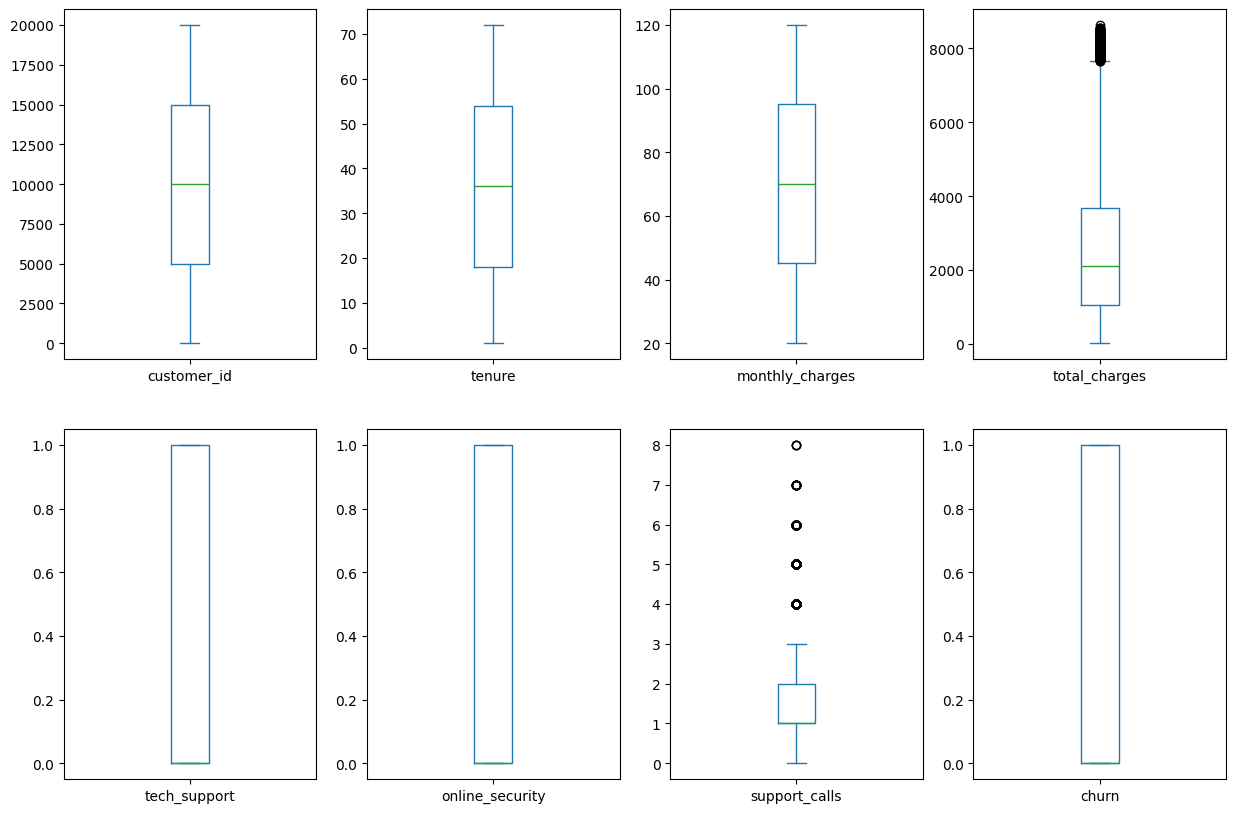

In [14]:
df_dados.select_dtypes(include= [np.number]).plot(kind= 'box', subplots= True, sharex= False, sharey= False, layout= (2,4), figsize= (15,10))

In [15]:
# contanto total de outliers
dados_num = df_dados.select_dtypes(include= [np.number])
Q1 = dados_num.quantile(0.25)
Q3 = dados_num.quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3  + 1.5 * IQR
outliers = ((dados_num < lim_inf) | (dados_num > lim_sup)).sum()
outliers

customer_id           0
tenure                0
monthly_charges       0
total_charges       177
tech_support          0
online_security       0
support_calls      1325
churn                 0
dtype: int64

Como existem 1502 outliers e essa é uma quantidade menor que 10 % dos dados, irei optar por retirar esses dados do dataframe.

In [16]:
df_dados = df_dados[~((dados_num < lim_inf) | (dados_num > lim_sup)).any(axis= 1)]
df_dados.shape

(18514, 11)

A coluna de Costumer_id é apenas um identifcador do cliente. Portanto, por não fazer inflenciar o churn, eu irei retirá-la.

In [17]:
df_dados.drop(columns= 'customer_id', inplace= True)

Correlação entre as variáveis

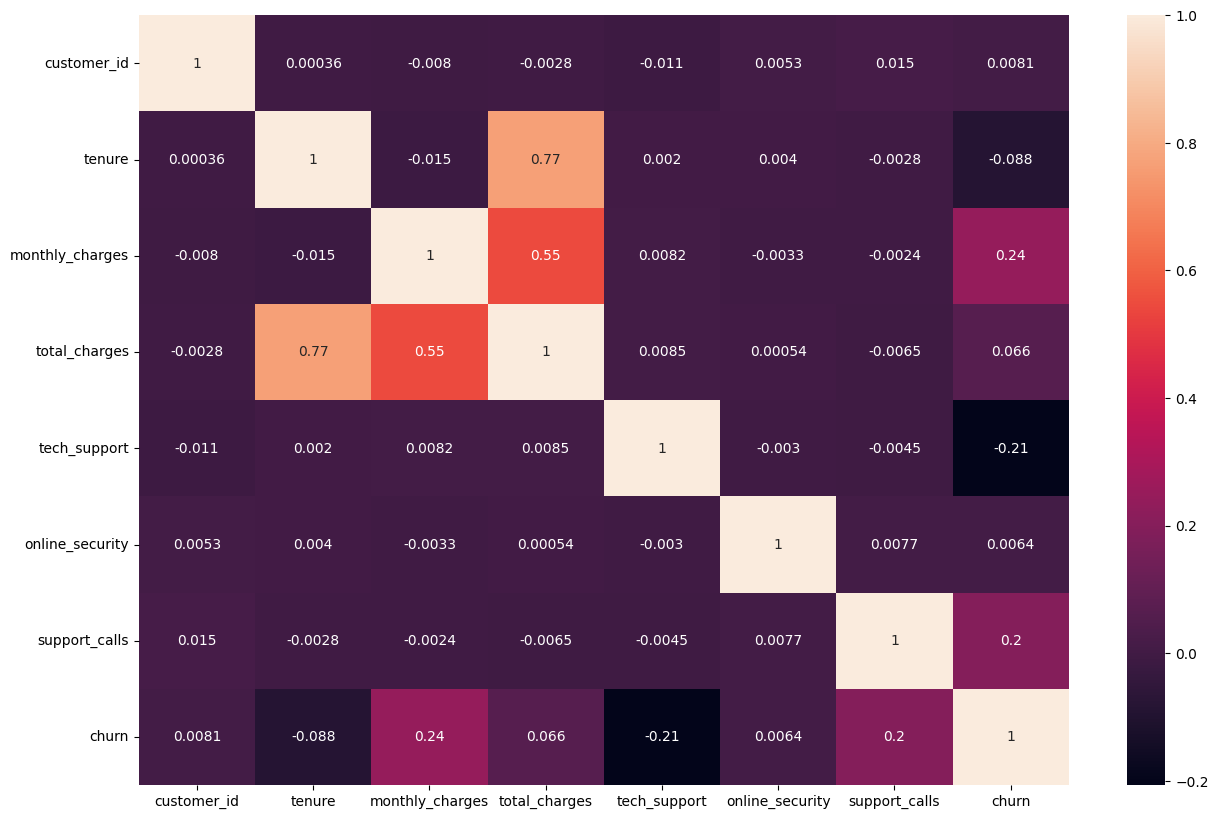

In [18]:
plt.figure(figsize= (15,10))
sns.heatmap(data = dados_num.corr(), annot= True)
plt.show()

visualização de como a variável churn é separada olhando-se para pares das outras variáveis

In [19]:
# plt.figure(figsize= (15,10))
# sns.pairplot(data = dados_num, kind = 'scatter', hue = 'churn')
# plt.show()

Olhando o gráfico acima, fica visível a complexidade de separação dos dados quanto ao churn. 
Provavelmente ,quando forem testados os modelos de classificação, irá ocorrer um overfitting dos algoritmos para conseguir encontrar "caminhos" que possam classificar essa variável.

### preparação dos dados para ML

In [20]:
# aplicando one hot encoding 
df_dados = pd.get_dummies(df_dados)


In [21]:
# separando o conjunto de dados
X = df_dados.drop(columns= ['churn'])
y = df_dados['churn']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size= 0.1, random_state= 42)

In [22]:
# padronizando as colunas numéricas (não binárias)

colunas = ['tenure', 'monthly_charges', 'total_charges','support_calls']

scaler = StandardScaler()
X_treino[colunas] = scaler.fit_transform(X_treino[colunas])
X_teste[colunas] = scaler.transform(X_teste[colunas])

### Criação dos modelos e avaliação

antes de mais nada, é importante lembrar que a variável alvo é desbalanceada. Por causa disso, irei testar o desempenho dos modelos em três situações:

* Sem balacemanto de classes



* Com balanceamento de Classes

    1 - Undersampling

    2 - Oversampling

### Sem Balanceamento

In [23]:
gerar_modelos(X_treino, y_treino, X_teste, y_teste)

Modelo:  Árvore simples 

Acurácia (treino):  1.0
Acurácia (teste):  0.7165226781857451 


Modelo:  Floresta Aleatória 

Acurácia (treino):  1.0
Acurácia (teste):  0.83207343412527 


Modelo:  Naive Bayes 

Acurácia (treino):  0.7366462609530668
Acurácia (teste):  0.7354211663066955 




### Balanceamento das classes (undersampling)

In [24]:
# base de treinamento balanceada

X_under, y_under = undersampling(X_treino, y_treino)

gerar_modelos(X_treino= X_under, y_treino= y_under, X_teste= X_teste, y_teste = y_teste)

Modelo:  Árvore simples 

Acurácia (treino):  1.0
Acurácia (teste):  0.6781857451403888 


Modelo:  Floresta Aleatória 

Acurácia (treino):  0.9999071149916403
Acurácia (teste):  0.7975161987041036 


Modelo:  Naive Bayes 

Acurácia (treino):  0.6643135797882221
Acurácia (teste):  0.6501079913606912 




### Balanceamento das classes (oversampling)

In [33]:
# usando o pacote SMOTE de imbalanced learn

sm = SMOTE(random_state= 0, k_neighbors= 50)

X_res, y_res = sm.fit_resample(X_treino, y_treino)

gerar_modelos(X_res, y_res, X_teste, y_teste)

Modelo:  Árvore simples 

Acurácia (treino):  1.0
Acurácia (teste):  0.7213822894168467 


Modelo:  Floresta Aleatória 

Acurácia (treino):  1.0
Acurácia (teste):  0.8196544276457883 


Modelo:  Naive Bayes 

Acurácia (treino):  0.6994414398439578
Acurácia (teste):  0.6706263498920086 




### Modelo escolhido : Random Forest

Para os 3 casos testados, O Random Forest se mostrou sendo o melhor modelo. Para decidir sobre o melhor caso, vou analisar também métricas específicas desse modelo como Precision, Recall e F1-Score.

In [28]:
modelo = RandomForestClassifier()
print('Sem Balanceamento')
avaliar_modelo(modelo, X_treino= X_treino, y_treino=y_treino, X_teste= X_teste, y_teste=y_teste)


Sem Balanceamento
           Churn(prev)=Não  Prev. Churn(prev)=Sim
Churn=Não             1153                     86
Churn=Sim              230                    383 


              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1239
           1       0.82      0.62      0.71       613

    accuracy                           0.83      1852
   macro avg       0.83      0.78      0.79      1852
weighted avg       0.83      0.83      0.82      1852
 




In [29]:
print('Undersampling')
avaliar_modelo(modelo, X_treino= X_under, y_treino=y_under, X_teste= X_teste, y_teste=y_teste)

Undersampling
           Churn(prev)=Não  Prev. Churn(prev)=Sim
Churn=Não             1061                    178
Churn=Sim              215                    398 


              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1239
           1       0.69      0.65      0.67       613

    accuracy                           0.79      1852
   macro avg       0.76      0.75      0.76      1852
weighted avg       0.78      0.79      0.79      1852
 




In [30]:
print('Oversampling')
avaliar_modelo(modelo, X_treino= X_res, y_treino=y_res, X_teste= X_teste, y_teste=y_teste)

Oversampling
           Churn(prev)=Não  Prev. Churn(prev)=Sim
Churn=Não             1104                    135
Churn=Sim              220                    393 


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1239
           1       0.74      0.64      0.69       613

    accuracy                           0.81      1852
   macro avg       0.79      0.77      0.78      1852
weighted avg       0.80      0.81      0.80      1852
 




# Conclusão

A melhor estratégia considerando o melhor modelo foi desconsiderar o desbalanceamento das classes. Isso é devido ao descrescimento das métricas de avaliação tendo sido aplicados os balanceamentos. 


Justificativas:
*  aplicar undersampling acabou jogando muito informação relevante fora, prejudicando o modelo.

* o oversampling pode ter gerado amostras sintéticas que não representam os dados reais, piorando assim as métricas avaliadas.